# Actividad final
## Microcredencial en Ciencia de Datos — Universidad de Oviedo

**Objetivo**:   
**Dataset**:   
**Variable objetivo**: `variable`  

---

## Índice
1. Carga y exploración inicial

---

> **Cómo leer este notebook**: Cada sección comienza con una explicación en texto de **qué vamos a hacer** y **por qué**. Después viene el código. Al final de cada sección hay una celda de conclusiones. No ejecutes el código antes de leer el texto — el análisis es tan importante como el resultado.

---
## 0. Carga de librerías

Importamos todas las librerías que necesitamos. Usamos `warnings.filterwarnings('ignore')` para no contaminar la salida del notebook con avisos de deprecación — en producción lo quitaríamos.

In [69]:
pip install pandas numpy matplotlib seaborn scipy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler

---
## 1. Carga y exploración inicial

### ¿Qué hacemos aquí?
Antes de hacer nada con los datos, necesitamos responder cuatro preguntas básicas:
1. **¿Cuántas filas y columnas tiene el dataset?** — escala del problema
2. **¿Qué tipo tiene cada variable?** — determina qué operaciones son aplicables
3. **¿Hay valores perdidos?** — dónde están y cuántos
4. **¿Qué rango de valores tiene cada variable?** — detectar si los números tienen sentido

### ¿Por qué es importante?
Un error muy común es empezar a transformar datos sin haberlos entendido. El resultado es transformaciones incorrectas que introducen errores silenciosos — el código corre sin error pero los datos están mal.

In [71]:
data = pd.read_csv("data/aug_train.csv")

In [72]:
data.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


**Observación**: Muchas variable de tipo `object` (texto). Pocas numéricas. Destacar que *target* parace binaria (0/1). Esto determina que tendremos que aplicar codificación (OHE) a a las de tipo object, mientras que las numéricas pueden entrar directamente (tras limpieza).

In [73]:
data.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

**Observación**: Varias variables con valores perdidos. Ahora sabemos que existe el problema. 
Revisar en la sección Imputación de valores perdidos decidiremos cómo imputarlo con información extra que obtendremos del EDA.

In [74]:
data.describe().round(2)

,enrollee_id,city_development_index,training_hours,target
count,19158.00,19158.00,19158.00,19158.00
mean,16875.36,0.83,65.37,0.25
std,9616.29,0.12,60.06,0.43
min,1.00,0.45,1.00,0.00
25%,8554.25,0.74,23.00,0.00
50%,16982.50,0.90,47.00,0.00
75%,25169.75,0.92,88.00,0.00
max,33380.00,0.95,336.00,1.00


Las que me pueden llamar la atención son training hours y enrolled_id... valores muy extremos

---
## 2. Análisis exploratorio univariado

### ¿Qué hacemos aquí?
Analizamos cada variable por separado. El objetivo es entender:
- **La forma de la distribución**: ¿simétrica? ¿asimétrica? ¿bimodal?
- **La presencia de outliers**: ¿hay valores extremos que se alejan mucho del grueso?
- **La distribución de la variable categórica**: ¿están bien balanceadas las categorías?

### ¿Por qué es importante?
La forma de la distribución determina qué transformaciones son apropiadas. Una distribución muy asimétrica puede perjudicar a ciertos modelos (la regresión lineal asume que los residuos son normales). Los outliers extremos distorsionan el escalado y afectan al entrenamiento.

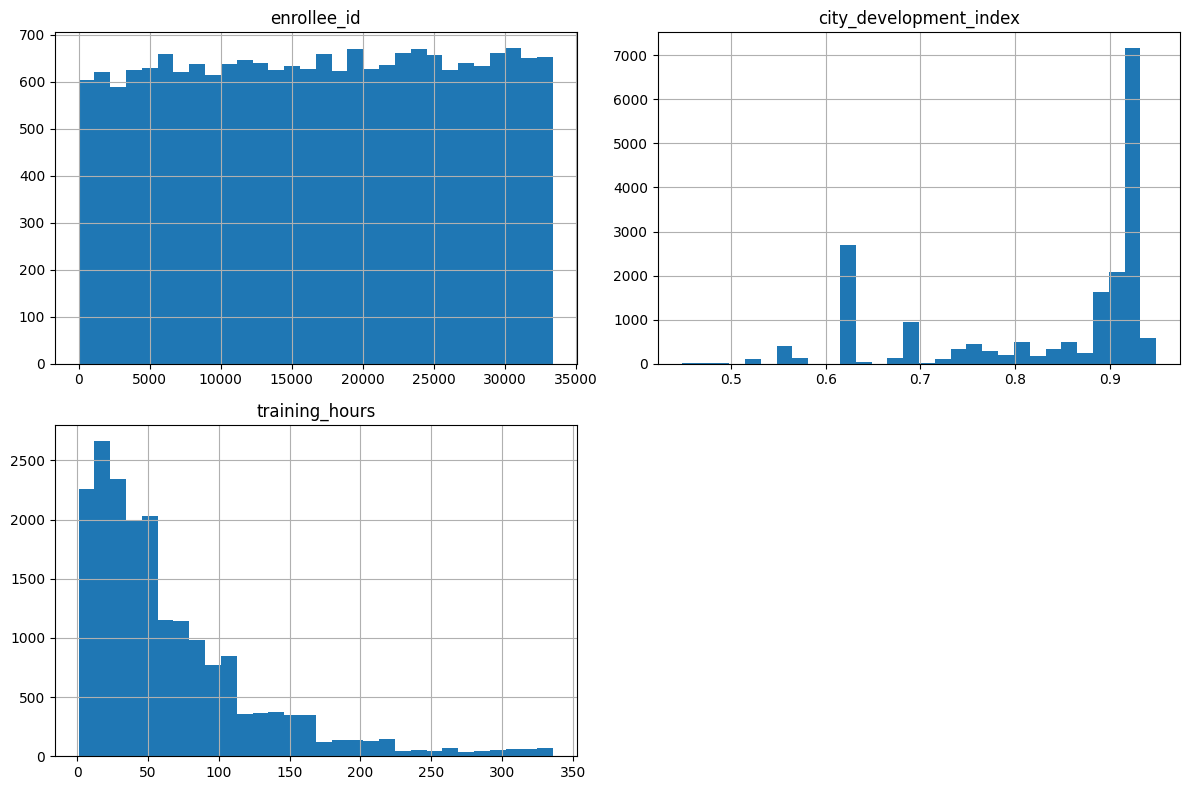

In [75]:
data.drop(["target"], axis=1).hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

**Observaciones de los histogramas:**
- enrolled_id uniforme
- city development index muy variada de 0,5-1
- training hours Distribución asimétrica moderada, con cola a la derecha.

In [76]:
cols_para_hist = data.drop(["target"], axis=1).select_dtypes(include='number').columns

In [77]:
cols_para_hist

Index(['enrollee_id', 'city_development_index', 'training_hours'], dtype='object')

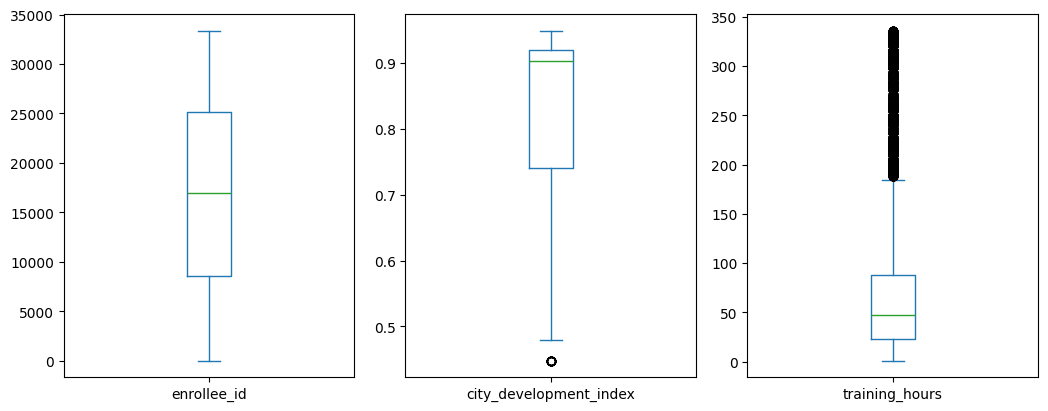

In [78]:
data[cols_para_hist].plot(kind="box", subplots=True, layout=(2,4),
                         figsize=(14,8), sharey=False)
plt.tight_layout()
plt.show()

Observaciones de los boxplots:

- enrolle_id equilibrada.
- city_development_index:  La caja (P25–P75) es grande, tiene outlier hacia abajo.
- training hours: La caja (P25–P75) es pequeña pero hay una cola enorme hacia arriba. Los puntos rojos son outliers visuales. Estos valores extremos distorsionarán el escalado y pueden afectar al entrenamiento — los trataremos en la sección *Tratamiento de outliers*.

In [ ]:
cols_para_bar = data.drop(["enrollee_id", "city_development_index", "training_hours"], axis=1).select_dtypes(include='number').columns

In [80]:
cols_para_bar

Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',
       'company_type', 'last_new_job'],
      dtype='object')

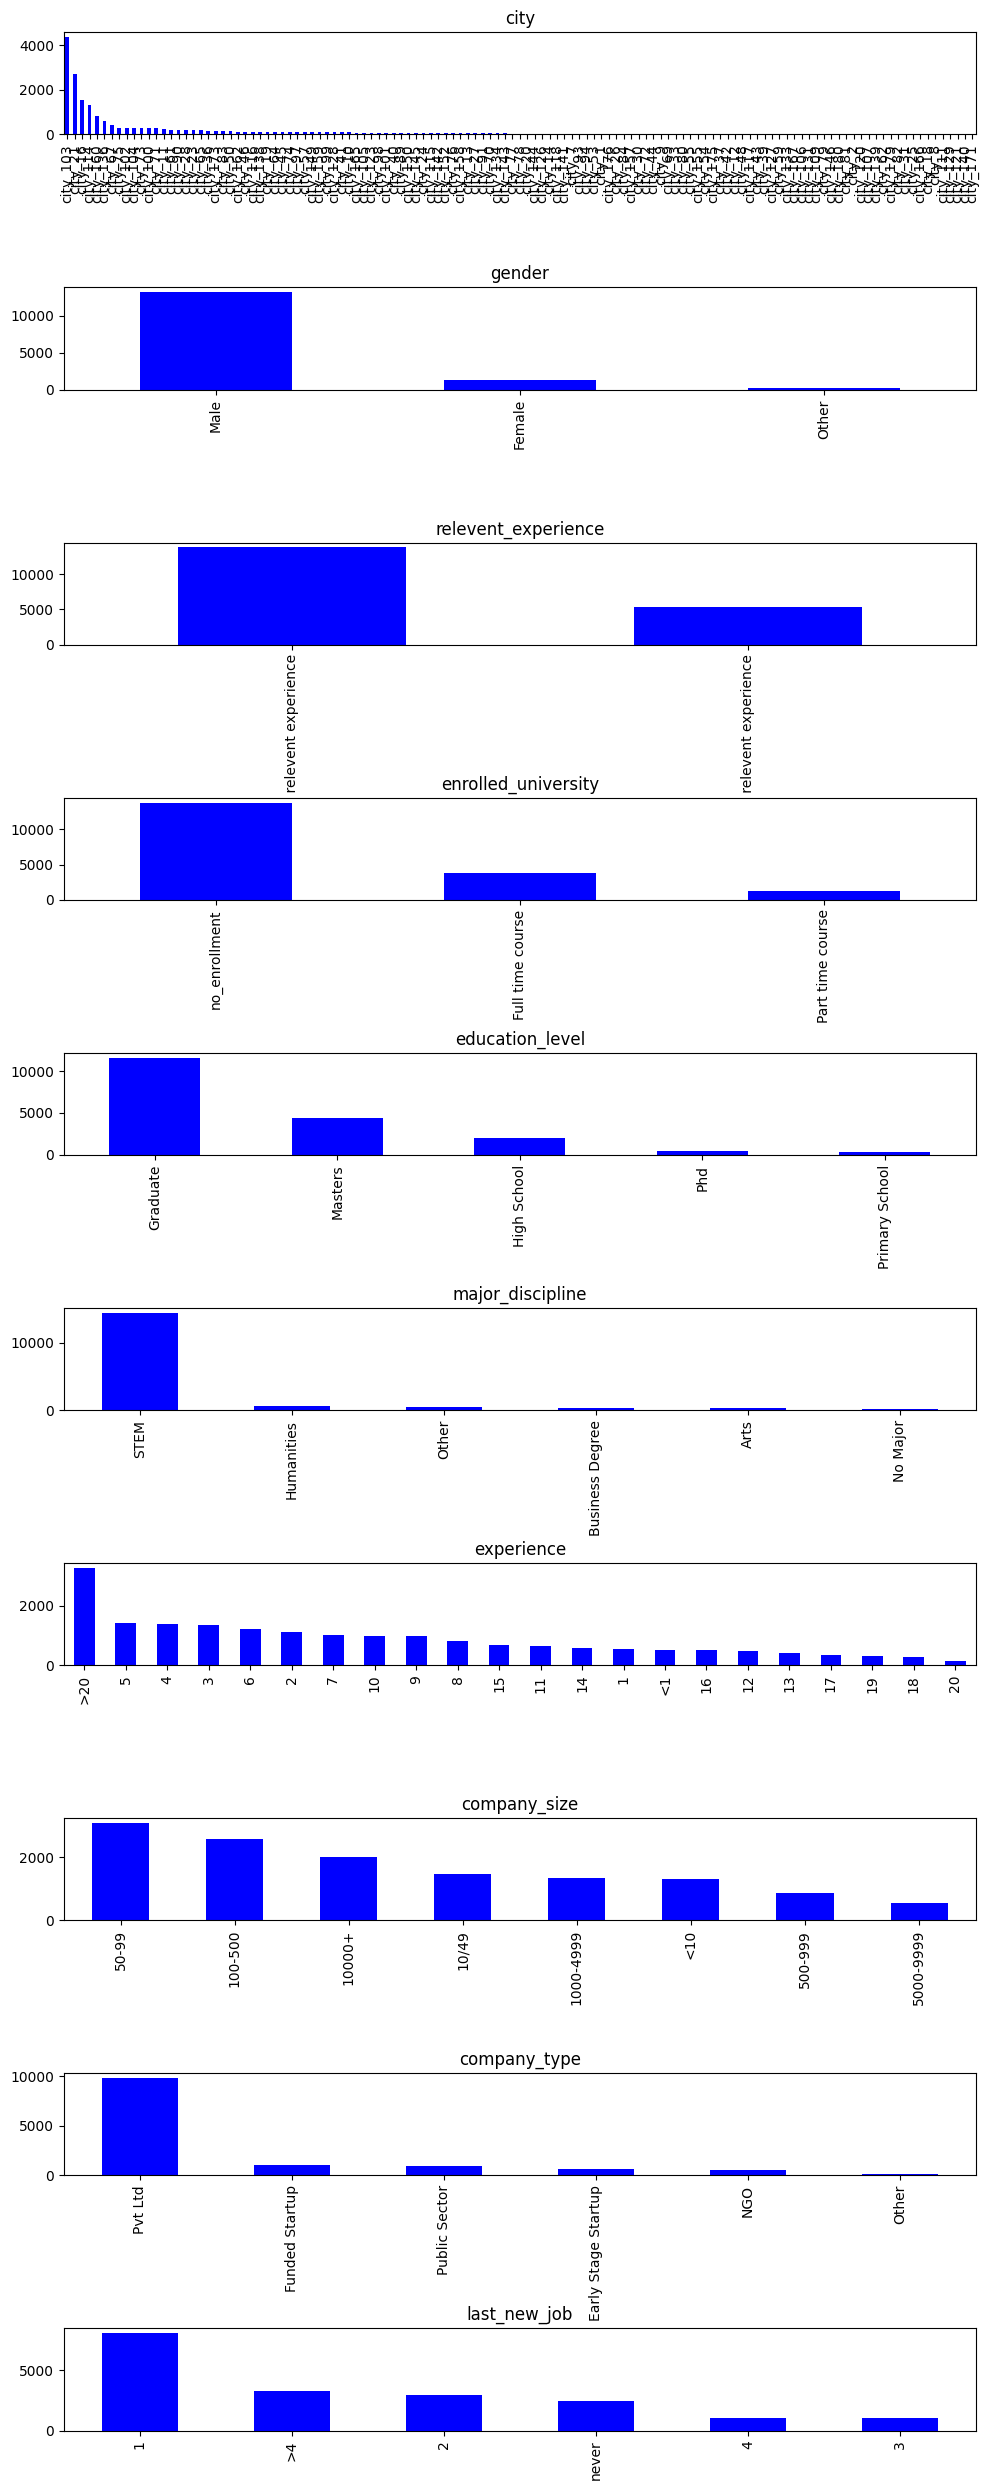

In [81]:
fig, axes = plt.subplots(len(cols_para_bar), 1, figsize=(10, 25))

for col, ax in zip(cols_para_bar, axes):
    data[col].value_counts().plot(kind="bar", ax=ax, color="blue")
    ax.set_title(col)
    ax.set_xlabel("")  # opcional: limpia el eje

plt.tight_layout()
fig.subplots_adjust(hspace=1.5)  # <--- AQUI SE SEPARAN
plt.show()


---
## 3. Análisis exploratorio bivariado

### ¿Qué hacemos aquí?
Analizamos las relaciones entre pares de variables, con foco especial en la relación de cada variable con el **target**?. Los análisis bivariados incluyen:
- **Matriz de correlaciones de Pearson**: para variables numéricas
- **Boxplots del target por categorías**: ?
- **Test de Kruskal-Wallis**: para contrastar estadísticamente si las diferencias entre categorías son significativas

### ¿Por qué es importante?
Las correlaciones nos indican qué variables tienen relación lineal con el target — señal de que serán predictores útiles. También detectamos **multicolinealidad** entre predictores (variables que miden lo mismo), lo que motivará la creación de ratios en el feature engineering.

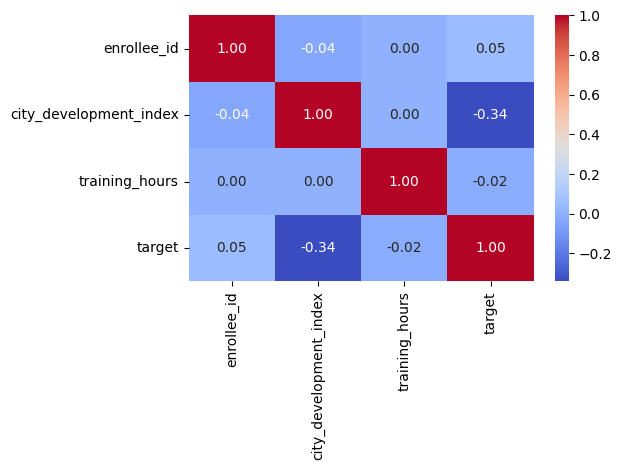

In [82]:
# Escribe aquí tu código
cols_para_pearson = data.select_dtypes(include='number').columns
corr = data[cols_para_pearson].corr()
sns.heatmap(corr, annot =True,fmt=".2f", cmap="coolwarm")
plt.tight_layout()
plt.show()

**Lecturas clave de la matriz de correlaciones:**


Variable	Correlación con target	Comentario
- city_development_index	−0.34	Correlación negativa moderada. A medida que el índice de desarrollo de la ciudad aumenta, la probabilidad de que el target sea positivo (por ejemplo, estar buscando empleo o tener cierta característica) tiende a disminuir.
- training_hours	−0.02	Prácticamente nula. Las horas de entrenamiento no parecen influir en el target.
- enrollee_id	0.05	Sin significado real; es solo un identificador. No debe usarse para análisis.

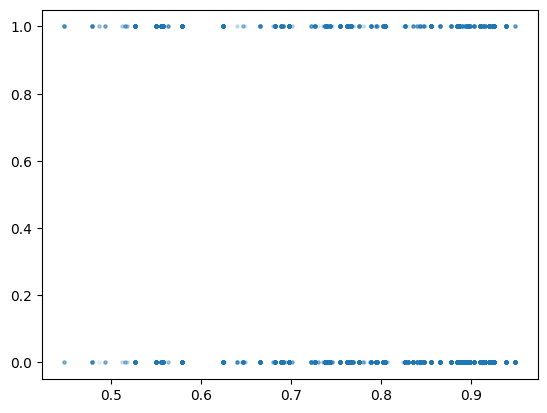

In [83]:
plt.scatter(data['city_development_index'], data['target'], alpha=0.1, s=5)
plt.show()

🧠 Interpretación
Correlación baja (≈ −0.34): el heatmap ya lo mostraba.

Visualmente: el scatter confirma que los valores del índice no separan bien las clases.

Conclusión: esta variable por sí sola no explica el comportamiento del target.

In [84]:
data.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

In [85]:
data.groupby("enrolled_university")["target"].mean().sort_values(ascending=False)

enrolled_university
Full time course    0.380889
Part time course    0.252087
no_enrollment       0.211406
Name: target, dtype: float64

In [86]:
# check distribution of target for enrolled_university == 'no_enrollment'
no_enroll = data[data['enrolled_university'] == 'no_enrollment']
print(no_enroll['target'].value_counts())
print("Fraction target==1:", (no_enroll['target'] == 1).mean())

target
0.0    10896
1.0     2921
Name: count, dtype: int64
Fraction target==1: 0.21140623869146705


C:\Users\alejo\AppData\Local\Temp\ipykernel_34932\2063327819.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\alejo\AppData\Local\Temp\ipykernel_34932\2063327819.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\alejo\AppData\Local\Temp\ipykernel_34932\2063327819.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\alejo\AppData\Local\Temp\ipykernel_34932\2063327819.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

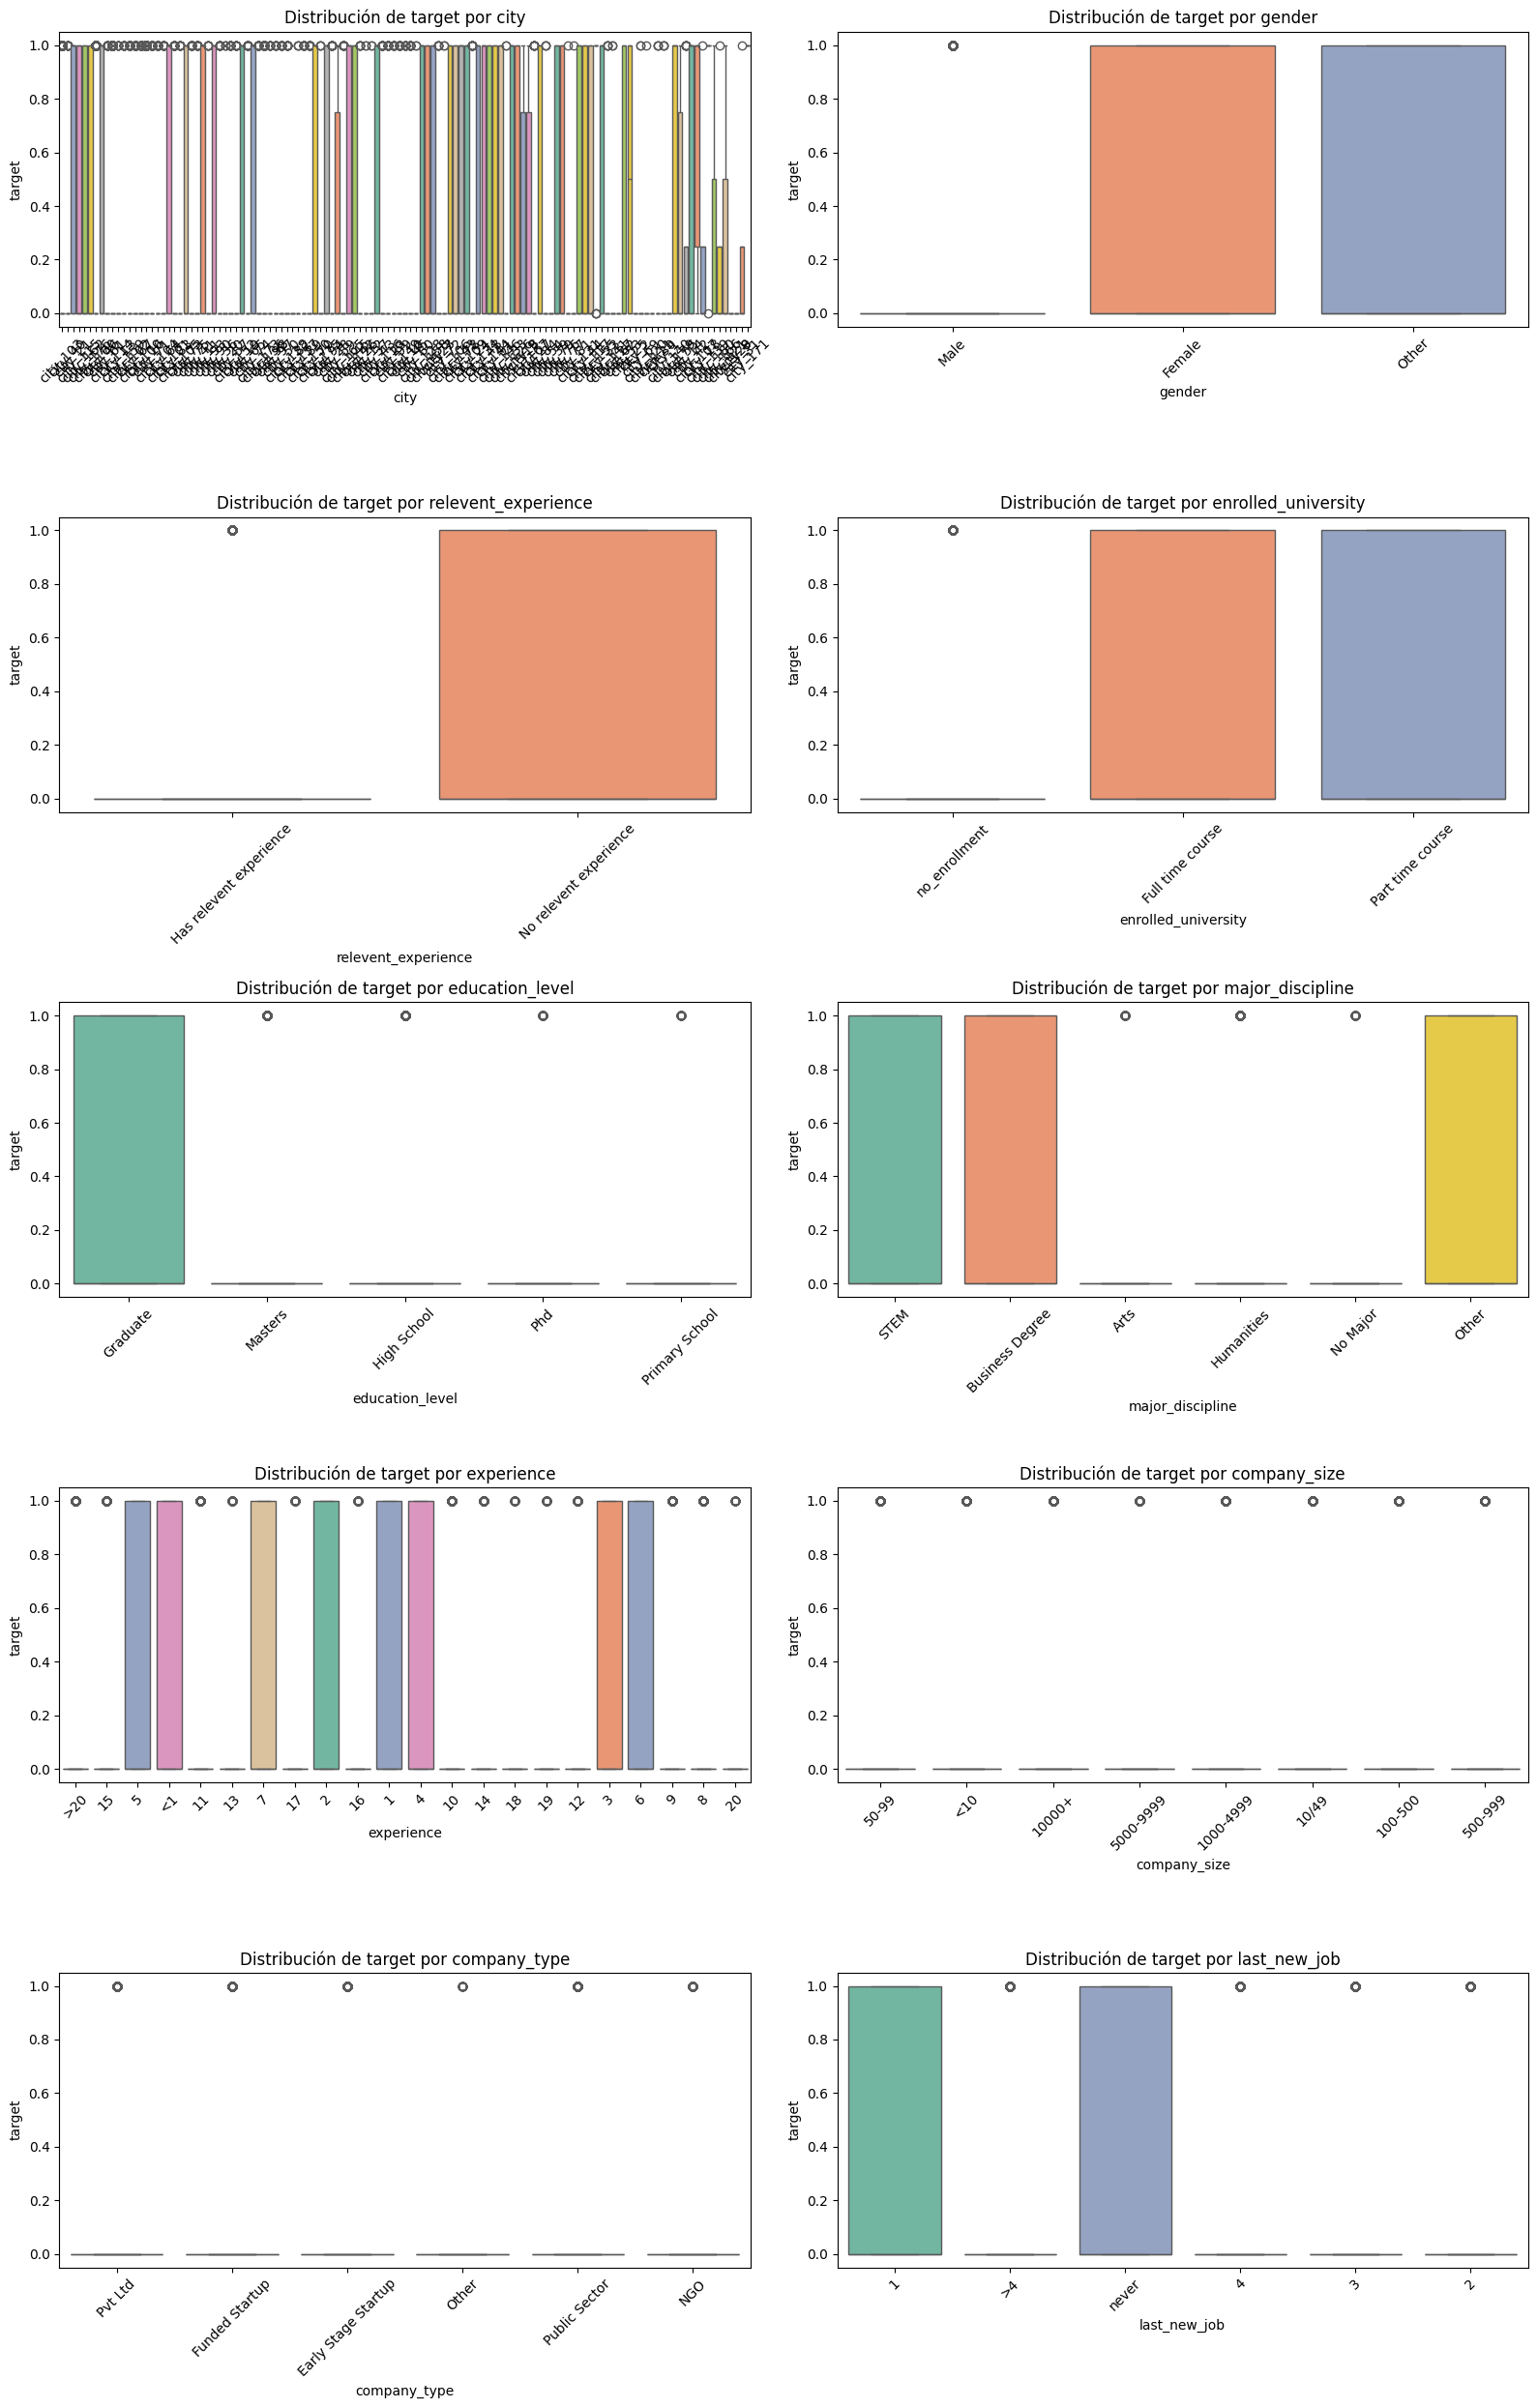

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar columnas categóricas
cat_cols = data.select_dtypes(include="object").columns

# Crear grid automático
n = len(cat_cols)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(
        x=col,
        y="target",
        data=data,
        ax=axes[i],
        palette="Set2"
    )
    axes[i].set_title(f"Distribución de target por {col}")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel("target")

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

🧠 Conclusión general
Algunas variables categóricas (como relevent_experience, education_level, enrolled_university) sí muestran patrones claros.

Otras (como company_size, company_type) no aportan información útil para el target.

Los boxplots son útiles para detectar asimetrías y outliers, pero para un target binario, los barplots con medias son más interpretables.

In [91]:
col = "enrolled_university"
data.groupby(col)["target"].mean().sort_values(ascending=False)

enrolled_university
Full time course    0.380889
Part time course    0.252087
no_enrollment       0.211406
Name: target, dtype: float64

C:\Users\alejo\AppData\Local\Temp\ipykernel_34932\1323204855.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="enrolled_university", y="target", data=data, estimator=np.mean, palette="Blues")


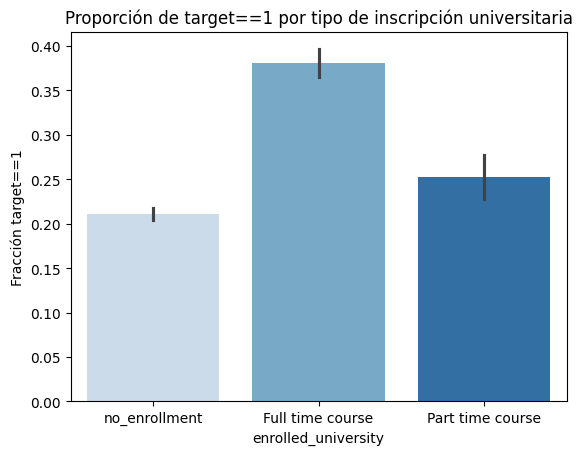

In [92]:
sns.barplot(x="enrolled_university", y="target", data=data, estimator=np.mean, palette="Blues")
plt.title("Proporción de target==1 por tipo de inscripción universitaria")
plt.ylabel("Fracción target==1")
plt.show()

🧠 Por qué el gráfico anterior se veía mal
El boxplot mostraba los valores individuales de target (0 o 1) por categoría, no la media.
Por eso todas las cajas parecían “planas” en 0 y 1, y no reflejaban la diferencia de proporciones.

Para visualizar correctamente esta diferencia, el mejor gráfico es el barplot con estimator=np.mean, que muestra la fracción promedio de target==1 por categoría.